# 02 - Comparing four models
BCS 3101 Capstone: predicting telecom customer churn

This notebook rebuilds the same data loading and pipeline from notebook 01, then trains and compares **four different types of model**:

1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbours (KNN)
4. Random Forest

Each one makes predictions in a completely different way. We score all four the same fair way and
compare them side by side.

## Step 1: Rebuild the data and pipeline (same as notebook 01)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style='whitegrid')

# --- load and clean, exactly as in notebook 01 ---
df = pd.read_csv('../data/raw/telco.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['customerID'])
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# --- same pipeline as notebook 01 ---
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
category_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

numeric_steps = Pipeline([
    ('fill_missing', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
category_steps = OneHotEncoder(handle_unknown='ignore')

preprocessing = ColumnTransformer([
    ('numbers', numeric_steps, numeric_columns),
    ('categories', category_steps, category_columns),
])

print('Training rows:', X_train.shape[0])
print('Testing rows: ', X_test.shape[0])
print('Pipeline rebuilt.')

Training rows: 5634
Testing rows:  1409
Pipeline rebuilt.


## Step 2: Set up fair testing
We use the same 5-fold cross-validation as notebook 01, and the same three scores
(accuracy, F1, ROC-AUC), so that we judge every model the exact same way.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

def evaluate(model, name):
    """Run 5-fold cross-validation on a model and return its average scores as one row."""
    full_model = Pipeline([
        ('preprocessing', preprocessing),
        ('model', model),
    ])
    results = cross_validate(full_model, X_train, y_train, cv=cv, scoring=scoring)

    row = {'model': name}
    for score_name in scoring:
        scores = results['test_' + score_name]
        row[score_name + ' (mean)'] = round(scores.mean(), 3)
        row[score_name + ' (spread)'] = round(scores.std(), 3)
    return row

print('Ready to evaluate models.')

Ready to evaluate models.


## Step 3: Model 1 - Logistic Regression
**How it works:** logistic regression gives every feature a weight (a number showing
how much it pushes the prediction toward "churn" or "no churn"), adds them all up, and squeezes the
result into a probability between 0 and 1. It's simple, fast, and easy to explain  - "longer contracts push the score down, month-to-month pushes it up."



In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
row_log_reg = evaluate(log_reg, 'Logistic Regression')
row_log_reg

{'model': 'Logistic Regression',
 'accuracy (mean)': np.float64(0.803),
 'accuracy (spread)': np.float64(0.012),
 'f1 (mean)': np.float64(0.593),
 'f1 (spread)': np.float64(0.03),
 'roc_auc (mean)': np.float64(0.846),
 'roc_auc (spread)': np.float64(0.013)}

## Step 4: Model 2 - Decision Tree
**How it works:** a decision tree asks a series of yes/no questions about the data
("Is Contract = month-to-month? Is tenure less than 12?") and follows the answers down a tree of
branches until it reaches a final prediction. It's easy to draw and explain, but on its own it can
"memorise" the training data too closely i.e overfitting.

**We gave it:** `max_depth=6`. This limits how many questions deep the tree can go. Without
a limit, the tree keeps splitting until it has practically memorised the training data, which makes
it very good on training data and much worse on new data.

In [4]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
row_tree = evaluate(tree, 'Decision Tree')
row_tree

{'model': 'Decision Tree',
 'accuracy (mean)': np.float64(0.789),
 'accuracy (spread)': np.float64(0.012),
 'f1 (mean)': np.float64(0.564),
 'f1 (spread)': np.float64(0.03),
 'roc_auc (mean)': np.float64(0.824),
 'roc_auc (spread)': np.float64(0.016)}

## Step 5: Model 3 - K-Nearest Neighbours (KNN)
**How it works:** to predict a new customer, KNN looks at the K most SIMILAR
customers already in the training data (measuring similarity as distance across all the features)
and takes a majority vote of what they did. No "learning" happens beforehand - it just compares at
prediction time.

**We gave it:** `n_neighbors=15`. This is K - how many similar customers to compare against.
Too small (like K=1) and one odd neighbour can flip the answer. Too large and it starts ignoring
real local patterns. 15 is a reasonable middle ground for a dataset this size.

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
row_knn = evaluate(knn, 'K-Nearest Neighbours')
row_knn

{'model': 'K-Nearest Neighbours',
 'accuracy (mean)': np.float64(0.787),
 'accuracy (spread)': np.float64(0.008),
 'f1 (mean)': np.float64(0.585),
 'f1 (spread)': np.float64(0.014),
 'roc_auc (mean)': np.float64(0.824),
 'roc_auc (spread)': np.float64(0.009)}

## Step 6: Model 4 - Random Forest
**How it works:** a random forest builds MANY decision trees,
each one trained on a slightly different random sample of the data, and then lets them vote. A single
tree can be a bit unstable; averaging many "wobbly" trees together usually gives a steadier, more
accurate result. This is called an ensemble method.

**We set the paremeters such as:**
- `n_estimators=200` - how many trees to build. More trees generally means steadier results, at the
  cost of taking longer to run.
- `max_depth=8` - same idea as the single decision tree above: stops each individual tree from
  memorising the training data.

In [6]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
row_forest = evaluate(forest, 'Random Forest')
row_forest

{'model': 'Random Forest',
 'accuracy (mean)': np.float64(0.803),
 'accuracy (spread)': np.float64(0.011),
 'f1 (mean)': np.float64(0.571),
 'f1 (spread)': np.float64(0.02),
 'roc_auc (mean)': np.float64(0.846),
 'roc_auc (spread)': np.float64(0.01)}

## Step 7: Compare all four models side by side

In [7]:
comparison = pd.DataFrame([row_log_reg, row_tree, row_knn, row_forest])
comparison = comparison.set_index('model')
comparison = comparison.sort_values('f1 (mean)', ascending=False)
comparison

,accuracy (mean),accuracy (spread),f1 (mean),f1 (spread),roc_auc (mean),roc_auc (spread)
model,,,,,,
Logistic Regression,0.803,0.012,0.593,0.030,0.846,0.013
K-Nearest Neighbours,0.787,0.008,0.585,0.014,0.824,0.009
Random Forest,0.803,0.011,0.571,0.020,0.846,0.010
Decision Tree,0.789,0.012,0.564,0.030,0.824,0.016


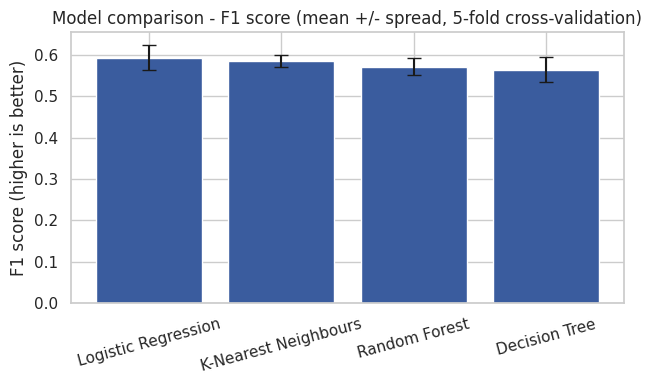

In [8]:
# a simple bar chart of the main score (F1) for each model, with the spread shown as error bars
plt.figure(figsize=(6.5, 4))
plt.bar(
    comparison.index,
    comparison['f1 (mean)'],
    yerr=comparison['f1 (spread)'],
    capsize=5,
    color='#3a5c9e',
)
plt.ylabel('F1 score (higher is better)')
plt.title('Model comparison - F1 score (mean +/- spread, 5-fold cross-validation)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/model_comparison_f1.png', dpi=150)
plt.show()



Logistic Regression has the highest average F1 score of 0.593, followed by K-Nearest Neighbours at 0.585, Random Forest at 0.571, and Decision Tree at 0.564. This means Logistic Regression performed best at identifying customers who are likely to churn while balancing precision and recall.

Logistic Regression has an F1 spread of 0.030, which is the same as the Decision Tree and higher than the spreads of K-Nearest Neighbours (0.014) and Random Forest (0.020). This means Logistic Regression achieved the highest average F1 score, but its performance varied more across the folds than those of K-Nearest Neighbours and Random Forest. K-Nearest Neighbours was the most consistent model based on its F1 spread.

We would choose Logistic Regression for further tuning because it achieved the highest average F1 score of 0.593 and tied with Random Forest for the highest average ROC-AUC of 0.846. Although its F1 score varied more across the folds, tuning its parameters may improve its performance and consistency. I would also consider Random Forest as a second model because it had the same average ROC-AUC and a slightly smaller F1 spread.


